# EDA: Le Plateau-Mont-Royal Station Density and H3 Clustering

## Objective
Analyze all BIXI stations in **Le Plateau-Mont-Royal** using **canonical station IDs**, then cluster stations using **H3 indexing** and visualize clusters.

## Plan
1. Build canonical station set for Le Plateau-Mont-Royal and compute station density stats.
2. (After your confirmation) Assign H3 indexes and form station clusters.
3. (After your confirmation) Visualize clusters on a map and summarize cluster characteristics.

I will stop after each step summary and ask for your approval before continuing.

In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession

BASE_DIR = Path.cwd()
RIDES_GLOB = str(BASE_DIR / "data" / "silver" / "rides" / "**" / "*.parquet")

DISTRICT_NAME = "Le Plateau-Mont-Royal"

con = duckdb.connect(database=":memory:")

schema_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{RIDES_GLOB}')").df()
all_cols = set(schema_df["column_name"].astype(str))

required_cols = {
    "start_canonical_station_id",
    "end_canonical_station_id",
    "start_station_latitude",
    "start_station_longitude",
    "end_station_latitude",
    "end_station_longitude",
    "start_station_district",
    "end_station_district",
}
missing = sorted(required_cols - all_cols)
if missing:
    raise ValueError(f"Missing required columns in rides dataset: {missing}")

canonical_station_sql = f"""
WITH station_obs AS (
    SELECT
        start_canonical_station_id AS canonical_station_id,
        start_station_district AS district,
        start_station_latitude AS latitude,
        start_station_longitude AS longitude
    FROM read_parquet('{RIDES_GLOB}')
    WHERE start_canonical_station_id IS NOT NULL
      AND start_station_latitude IS NOT NULL
      AND start_station_longitude IS NOT NULL

    UNION ALL

    SELECT
        end_canonical_station_id AS canonical_station_id,
        end_station_district AS district,
        end_station_latitude AS latitude,
        end_station_longitude AS longitude
    FROM read_parquet('{RIDES_GLOB}')
    WHERE end_canonical_station_id IS NOT NULL
      AND end_station_latitude IS NOT NULL
      AND end_station_longitude IS NOT NULL
),
station_district_votes AS (
    SELECT
        canonical_station_id,
        district,
        COUNT(*) AS district_votes
    FROM station_obs
    WHERE district IS NOT NULL
    GROUP BY 1, 2
),
station_primary_district AS (
    SELECT
        canonical_station_id,
        district,
        district_votes,
        ROW_NUMBER() OVER (
            PARTITION BY canonical_station_id
            ORDER BY district_votes DESC, district ASC
        ) AS rn
    FROM station_district_votes
),
station_centroids AS (
    SELECT
        canonical_station_id,
        AVG(latitude) AS latitude,
        AVG(longitude) AS longitude,
        COUNT(*) AS observation_count
    FROM station_obs
    GROUP BY 1
)
SELECT
    c.canonical_station_id,
    p.district,
    c.latitude,
    c.longitude,
    c.observation_count
FROM station_centroids c
JOIN station_primary_district p
  ON c.canonical_station_id = p.canonical_station_id
WHERE p.rn = 1
  AND p.district = '{DISTRICT_NAME}'
ORDER BY c.canonical_station_id
"""

plateau_stations_df = con.execute(canonical_station_sql).df()

if plateau_stations_df.empty:
    raise ValueError(
        f"No canonical stations found for district '{DISTRICT_NAME}'. Check district labels in source data."
    )

# Ensure Spark workers use this notebook's Python environment.
spark = (
    SparkSession.builder.master("local[*]")
    .appName("plateau-h3-clustering")
    .config("spark.pyspark.driver.python", sys.executable)
    .config("spark.pyspark.python", sys.executable)
    .getOrCreate()
)

print(f"District: {DISTRICT_NAME}")
print(f"Canonical stations found: {plateau_stations_df['canonical_station_id'].nunique():,}")
print(f"Spark Python executable: {sys.executable}")
plateau_stations_df.head()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/29 18:13:59 WARN Utils: Your hostname, YCLNVO-HOME, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/29 18:13:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/29 18:13:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


District: Le Plateau-Mont-Royal
Canonical stations found: 232
Spark Python executable: /home/yuchen/project/bixi-analytics/.venv/bin/python


,canonical_station_id,district,latitude,longitude,observation_count
0,STN_0001,Le Plateau-Mont-Royal,45.519410,-73.586850,577324
1,STN_0002,Le Plateau-Mont-Royal,45.524285,-73.581508,555441
2,STN_0003,Le Plateau-Mont-Royal,45.515228,-73.575096,433419
3,STN_0004,Le Plateau-Mont-Royal,45.527152,-73.589450,404106
4,STN_0005,Le Plateau-Mont-Royal,45.532245,-73.575435,396214


,metric,value
0,canonical_station_count,232.000
1,bbox_width_km,3.794
2,bbox_height_km,3.653
3,bbox_area_km2,13.858
4,stations_per_km2_bbox,16.740
5,nn_distance_median_m,82.200
6,nn_distance_p90_m,177.100
7,nn_distance_max_m,370.400


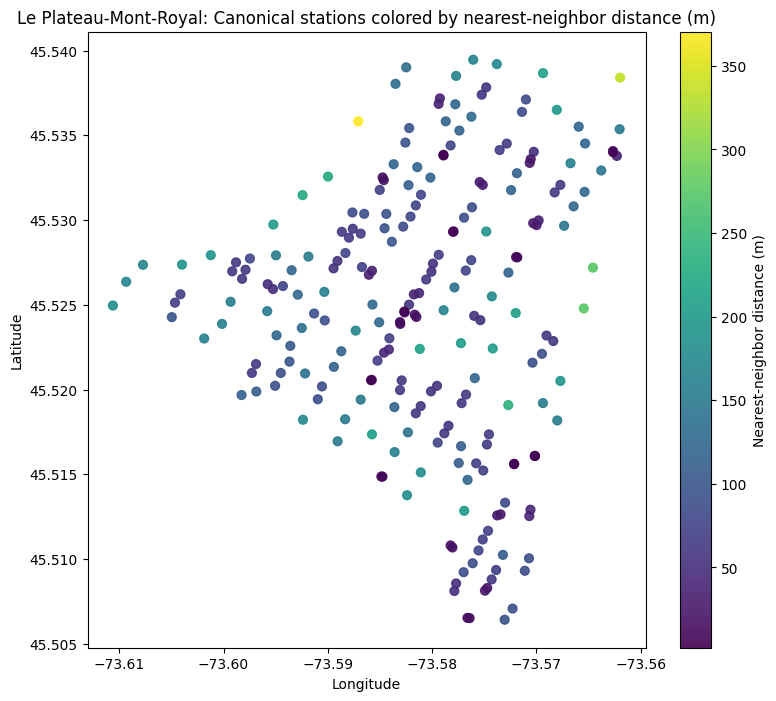

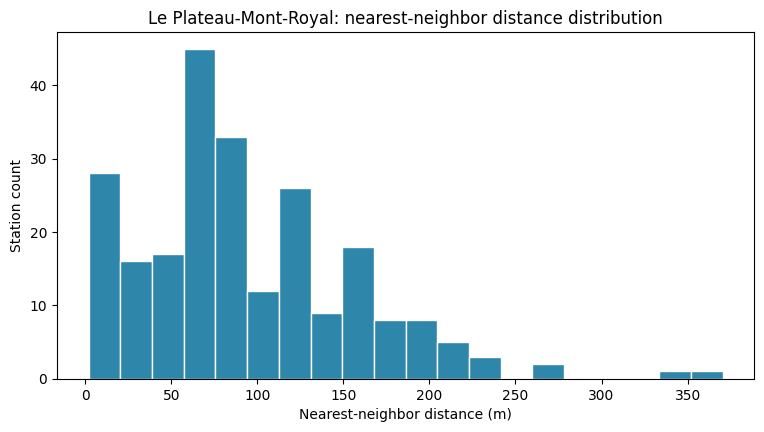

In [2]:
# Task 1: General station density stats before clustering
plot_df = plateau_stations_df.copy()

lat = plot_df["latitude"].to_numpy(dtype=float)
lon = plot_df["longitude"].to_numpy(dtype=float)

lat0 = float(np.mean(lat))
lon0 = float(np.mean(lon))

# Local metric projection (km): equirectangular approximation around district centroid
km_per_deg_lat = 110.574
km_per_deg_lon = 111.320 * np.cos(np.deg2rad(lat0))

x_km = (lon - lon0) * km_per_deg_lon
y_km = (lat - lat0) * km_per_deg_lat
coords_m = np.column_stack([x_km * 1000.0, y_km * 1000.0])

station_count = int(plot_df["canonical_station_id"].nunique())

bbox_width_km = float(np.max(x_km) - np.min(x_km))
bbox_height_km = float(np.max(y_km) - np.min(y_km))
bbox_area_km2 = bbox_width_km * bbox_height_km
stations_per_km2_bbox = station_count / bbox_area_km2 if bbox_area_km2 > 0 else np.nan

# Brute-force nearest-neighbor distance in meters
if station_count < 2:
    raise ValueError("Need at least 2 stations to compute nearest-neighbor spacing.")

delta = coords_m[:, None, :] - coords_m[None, :, :]
pairwise_m = np.sqrt(np.sum(delta**2, axis=2))
np.fill_diagonal(pairwise_m, np.inf)
nearest_m = np.min(pairwise_m, axis=1)

plot_df["nn_distance_m"] = nearest_m

stats_summary = pd.DataFrame(
    {
        "metric": [
            "canonical_station_count",
            "bbox_width_km",
            "bbox_height_km",
            "bbox_area_km2",
            "stations_per_km2_bbox",
            "nn_distance_median_m",
            "nn_distance_p90_m",
            "nn_distance_max_m",
        ],
        "value": [
            station_count,
            round(bbox_width_km, 3),
            round(bbox_height_km, 3),
            round(bbox_area_km2, 3),
            round(stations_per_km2_bbox, 2),
            round(float(np.median(nearest_m)), 1),
            round(float(np.quantile(nearest_m, 0.90)), 1),
            round(float(np.max(nearest_m)), 1),
        ],
    }
)

display(stats_summary)

# Visualization 1: spatial scatter in lon/lat, colored by nearest-neighbor spacing
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(
    plot_df["longitude"],
    plot_df["latitude"],
    c=plot_df["nn_distance_m"],
    cmap="viridis",
    s=40,
    alpha=0.9,
)
ax.set_title(f"{DISTRICT_NAME}: Canonical stations colored by nearest-neighbor distance (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Nearest-neighbor distance (m)")
plt.show()

# Visualization 2: histogram of nearest-neighbor distances
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(plot_df["nn_distance_m"], bins=20, color="#2E86AB", edgecolor="white")
ax.set_title(f"{DISTRICT_NAME}: nearest-neighbor distance distribution")
ax.set_xlabel("Nearest-neighbor distance (m)")
ax.set_ylabel("Station count")
plt.show()

In [22]:
# Task 2: H3 clustering with h3_pyspark (run only after Task 1 is reviewed)
try:
    import h3_pyspark
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "h3_pyspark is not available in the current notebook kernel environment. "
        "Please help confirm this kernel uses the same environment where h3-pyspark was installed."
    ) from exc

import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql import functions as F

# Patch through h3_pyspark only (no direct h3 import)
if not hasattr(h3_pyspark.h3, "geo_to_h3") and hasattr(h3_pyspark.h3, "latlng_to_cell"):
    h3_pyspark.h3.geo_to_h3 = h3_pyspark.h3.latlng_to_cell

H3_RESOLUTION = 9

# Compute H3 cells with h3_pyspark on driver to avoid Spark worker dependency mismatch.
station_h3_df = plot_df[["canonical_station_id", "latitude", "longitude"]].copy()
station_h3_df["h3_cell"] = station_h3_df.apply(
    lambda r: str(h3_pyspark.h3.geo_to_h3(float(r["latitude"]), float(r["longitude"]), int(H3_RESOLUTION))),
    axis=1,
)

sdf_h3 = spark.createDataFrame(station_h3_df)

cluster_stats_sdf = (
    sdf_h3.groupBy("h3_cell")
    .agg(
        F.countDistinct("canonical_station_id").alias("station_count"),
        F.avg("latitude").alias("cluster_lat"),
        F.avg("longitude").alias("cluster_lon"),
    )
    .orderBy(F.desc("station_count"), F.asc("h3_cell"))
)

cluster_stats_df = cluster_stats_sdf.toPandas()
display(cluster_stats_df)

plot_h3_df = station_h3_df.merge(cluster_stats_df[["h3_cell", "station_count"]], on="h3_cell", how="left")

# Build H3 polygon boundaries for plotting from h3_pyspark's underlying H3 API.
def _cell_boundary_lon_lat(cell_id: str):
    if hasattr(h3_pyspark.h3, "h3_to_geo_boundary"):
        # h3 v3-style API
        boundary = h3_pyspark.h3.h3_to_geo_boundary(cell_id)
    elif hasattr(h3_pyspark.h3, "cell_to_boundary"):
        # h3 v4-style API
        boundary = h3_pyspark.h3.cell_to_boundary(cell_id)
    else:
        raise AttributeError("No supported boundary API found on h3_pyspark.h3")

    # Normalize to (lon, lat) order for plotting and close polygon.
    lat_lon = [(float(p[0]), float(p[1])) for p in boundary]
    lon_lat = [(lon, lat) for lat, lon in lat_lon]
    if lon_lat[0] != lon_lat[-1]:
        lon_lat.append(lon_lat[0])
    return lon_lat

min_count = int(cluster_stats_df["station_count"].min())
max_count = int(cluster_stats_df["station_count"].max())

def _count_to_color(c):
    if max_count == min_count:
        return px.colors.sample_colorscale("Viridis", [0.6])[0]
    t = (c - min_count) / (max_count - min_count)
    return px.colors.sample_colorscale("Viridis", [t])[0]

fig_hex = go.Figure()
for row in cluster_stats_df.itertuples(index=False):
    cell_id = str(row.h3_cell)
    count = int(row.station_count)
    boundary = _cell_boundary_lon_lat(cell_id)
    lons = [p[0] for p in boundary]
    lats = [p[1] for p in boundary]
    color = _count_to_color(count)

    fig_hex.add_trace(
        go.Scatter(
            x=lons,
            y=lats,
            mode="lines",
            fill="toself",
            line=dict(color="white", width=1),
            fillcolor=color,
            hovertemplate=(
                f"H3 cell: {cell_id}<br>"
                f"Station count: {count}<extra></extra>"
            ),
            showlegend=False,
        )
    )

fig_hex.update_layout(
    title=f"{DISTRICT_NAME}: H3 hexagon clusters (resolution {H3_RESOLUTION})",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    yaxis_scaleanchor="x",
    template="plotly_white",
    height=700,
)
fig_hex.show()

# Visualization 2: stations per H3 cluster
cluster_stats_plot = cluster_stats_df.sort_values(["station_count", "h3_cell"], ascending=[False, True])
fig_bar = px.bar(
    cluster_stats_plot,
    x="h3_cell",
    y="station_count",
    color="station_count",
    color_continuous_scale="Viridis",
    title=f"{DISTRICT_NAME}: station count per H3 cell (resolution {H3_RESOLUTION})",
)
fig_bar.update_layout(xaxis_title="H3 cell", yaxis_title="Stations in cell", xaxis_tickangle=-90, height=450)
fig_bar.show()

,h3_cell,station_count,cluster_lat,cluster_lon
0,892baa44547ffff,9,45.523732,-73.583897
1,892baa445cbffff,8,45.532279,-73.582443
2,892baa46a4bffff,7,45.507401,-73.574609
3,892baa440a3ffff,6,45.520545,-73.596477
4,892baa44197ffff,6,45.509928,-73.577101
...,...,...,...,...
66,892baa44507ffff,1,45.521590,-73.570373
67,892baa44587ffff,1,45.527197,-73.564572
68,892baa445bbffff,1,45.524790,-73.565450
69,892baa445c3ffff,1,45.532245,-73.575435


In [23]:
# Task 3: Show clusters containing selected stations, with norm_names for all stations shown
selected_station_ids_raw = ["STN_0001", "\"\"STN_0002", "STN_0003", "STN_0004"]
selected_station_ids = [s.replace('"', '').strip() for s in selected_station_ids_raw if s and s.strip()]

# Recompute H3 assignment deterministically from canonical station coordinates
station_h3_df = plateau_stations_df[["canonical_station_id", "latitude", "longitude"]].copy()
station_h3_df["h3_cell"] = station_h3_df.apply(
    lambda r: str(h3_pyspark.h3.geo_to_h3(float(r["latitude"]), float(r["longitude"]), int(H3_RESOLUTION))),
    axis=1,
)

# Build canonical -> normalized station names mapping from rides data
norm_name_sql = f"""
WITH names_union AS (
    SELECT
        start_canonical_station_id AS canonical_station_id,
        lower(trim(regexp_replace(coalesce(start_station_name, ''), '\\s+', ' '))) AS norm_name
    FROM read_parquet('{RIDES_GLOB}')
    WHERE start_canonical_station_id IS NOT NULL
      AND start_station_name IS NOT NULL

    UNION ALL

    SELECT
        end_canonical_station_id AS canonical_station_id,
        lower(trim(regexp_replace(coalesce(end_station_name, ''), '\\s+', ' '))) AS norm_name
    FROM read_parquet('{RIDES_GLOB}')
    WHERE end_canonical_station_id IS NOT NULL
      AND end_station_name IS NOT NULL
),
name_counts AS (
    SELECT
        canonical_station_id,
        norm_name,
        COUNT(*) AS cnt
    FROM names_union
    WHERE norm_name <> ''
    GROUP BY 1, 2
)
SELECT
    canonical_station_id,
    LIST(norm_name ORDER BY cnt DESC, norm_name ASC) AS norm_names
FROM name_counts
GROUP BY 1
"""

canonical_norm_names_df = con.execute(norm_name_sql).df()

# DuckDB LIST may appear as list, tuple, numpy array, or pandas array-like.
def _normalize_name_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [str(v) for v in x]
    if isinstance(x, tuple):
        return [str(v) for v in x]
    if hasattr(x, "tolist"):
        vals = x.tolist()
        if isinstance(vals, list):
            return [str(v) for v in vals]
        return [str(vals)]
    return [str(x)]

canonical_norm_names_df["norm_names"] = canonical_norm_names_df["norm_names"].apply(_normalize_name_list)

station_enriched_df = station_h3_df.merge(canonical_norm_names_df, on="canonical_station_id", how="left")
station_enriched_df["norm_names"] = station_enriched_df["norm_names"].apply(
    lambda x: x if isinstance(x, list) else []
)

requested_df = station_enriched_df[station_enriched_df["canonical_station_id"].isin(selected_station_ids)].copy()
if requested_df.empty:
    raise ValueError(f"None of the requested station IDs were found: {selected_station_ids}")

target_h3_cells = sorted(requested_df["h3_cell"].unique().tolist())
focus_df = station_enriched_df[station_enriched_df["h3_cell"].isin(target_h3_cells)].copy()
focus_df["is_requested_station"] = focus_df["canonical_station_id"].isin(selected_station_ids)

cluster_size_df = (
    focus_df.groupby("h3_cell", as_index=False)
    .agg(cluster_station_count=("canonical_station_id", "nunique"))
    .sort_values(["cluster_station_count", "h3_cell"], ascending=[False, True])
)

display(cluster_size_df)

display(
    focus_df[
        [
            "h3_cell",
            "canonical_station_id",
            "is_requested_station",
            "norm_names",
            "latitude",
            "longitude",
        ]
    ].sort_values(["h3_cell", "is_requested_station", "canonical_station_id"], ascending=[True, False, True])
)

,h3_cell,cluster_station_count
1,892baa4452bffff,5
2,892baa44543ffff,4
3,892baa4457bffff,4
0,892baa4450bffff,3


,h3_cell,canonical_station_id,is_requested_station,norm_names,latitude,longitude
1,892baa4450bffff,STN_0002,True,[métro mont-royal (utilités publiques / rivard)],45.524285,-73.581508
71,892baa4450bffff,STN_0144,False,[marie-anne / st-hubert],45.524683,-73.578897
203,892baa4450bffff,STN_0948,False,[métro mont-royal (place gérald-godin)],45.524420,-73.581663
2,892baa4452bffff,STN_0003,True,[des pins / st-laurent],45.515228,-73.575096
31,892baa4452bffff,STN_0057,False,[st-dominique / napoléon],45.516664,-73.577220
87,892baa4452bffff,STN_0212,False,[roy / saint-laurent],45.515652,-73.575774
98,892baa4452bffff,STN_0255,False,[st-cuthbert / clark],45.515672,-73.577443
107,892baa4452bffff,STN_0290,False,[sewell / roy],45.514677,-73.576598
3,892baa44543ffff,STN_0004,True,[laurier / st-denis],45.527152,-73.589450
80,892baa44543ffff,STN_0188,False,[métro laurier (berri / st-joseph)],45.527231,-73.586726


In [24]:
# Compact view: requested clusters with station IDs + norm_names
compact_cols = [
    "h3_cell",
    "canonical_station_id",
    "is_requested_station",
    "norm_names",
]
compact_df = focus_df[compact_cols].sort_values(
    ["h3_cell", "is_requested_station", "canonical_station_id"],
    ascending=[True, False, True],
)

print("Requested station IDs (sanitized):", selected_station_ids)
print("Target H3 cells:", target_h3_cells)
print("\nStations in those clusters:")
print(compact_df.to_string(index=False))

Requested station IDs (sanitized): ['STN_0001', 'STN_0002', 'STN_0003', 'STN_0004']
Target H3 cells: ['892baa4450bffff', '892baa4452bffff', '892baa44543ffff', '892baa4457bffff']

Stations in those clusters:
        h3_cell canonical_station_id  is_requested_station                                       norm_names
892baa4450bffff             STN_0002                  True [métro mont-royal (utilités publiques / rivard)]
892baa4450bffff             STN_0144                 False                         [marie-anne / st-hubert]
892baa4450bffff             STN_0948                 False          [métro mont-royal (place gérald-godin)]
892baa4452bffff             STN_0003                  True                          [des pins / st-laurent]
892baa4452bffff             STN_0057                 False                        [st-dominique / napoléon]
892baa4452bffff             STN_0212                 False                            [roy / saint-laurent]
892baa4452bffff             STN_0255 

,h3_cell,canonical_station_id,total_traffic
0,892baa4450bffff,STN_0002,555441
1,892baa4450bffff,STN_0144,139917
2,892baa4450bffff,STN_0948,13507
3,892baa4452bffff,STN_0003,433419
4,892baa4452bffff,STN_0057,209600
5,892baa4452bffff,STN_0212,111030
6,892baa4452bffff,STN_0255,100246
7,892baa4452bffff,STN_0290,92855
8,892baa44543ffff,STN_0004,404106
9,892baa44543ffff,STN_0188,118809


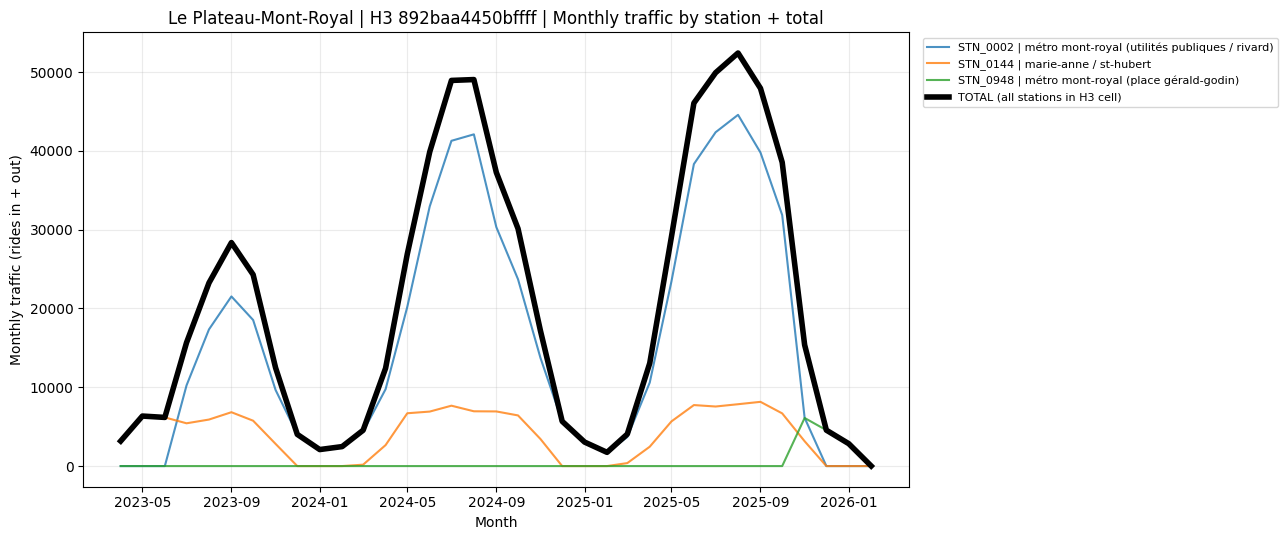

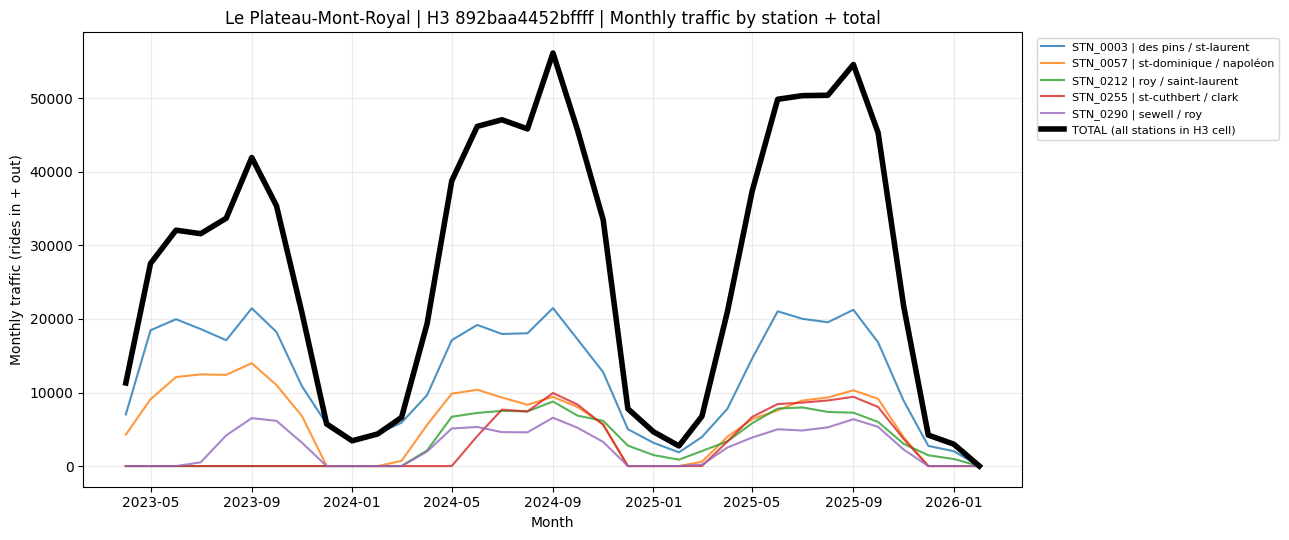

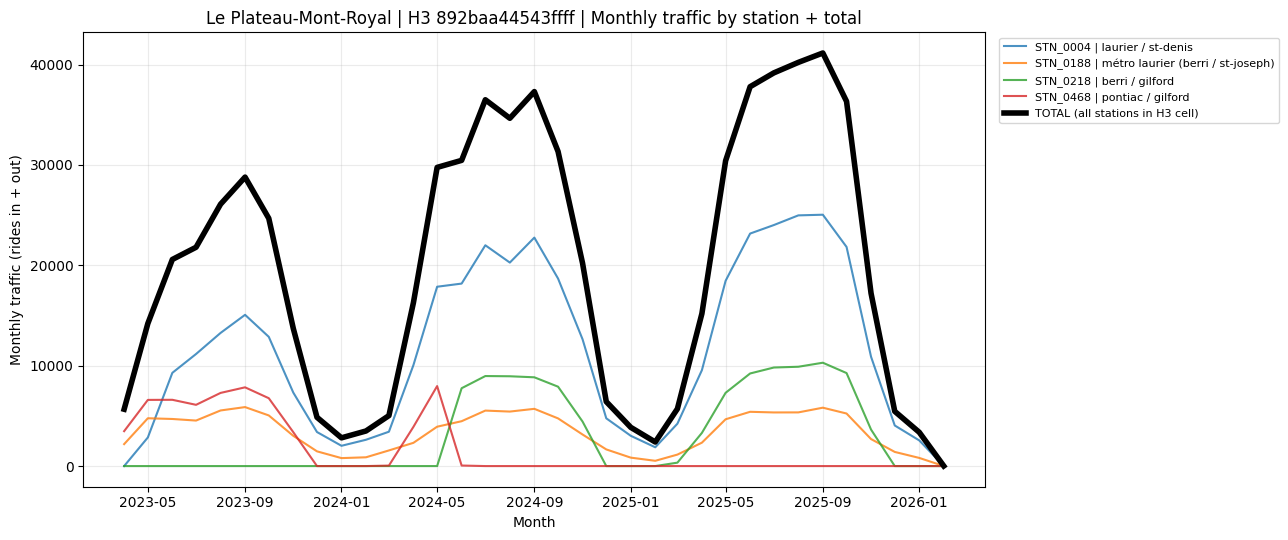

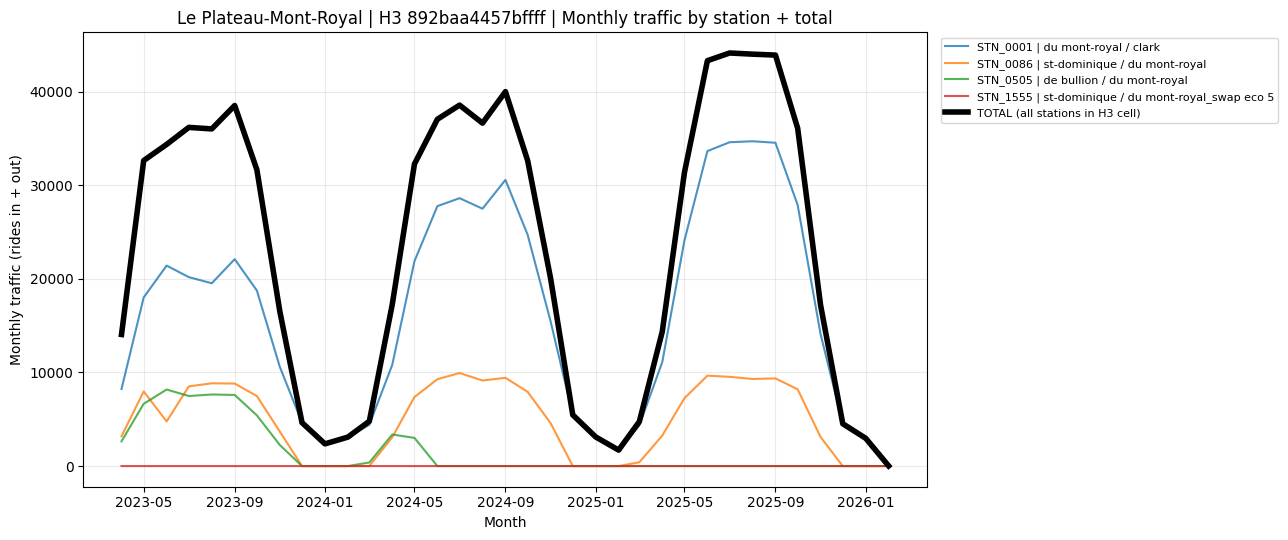

In [29]:
# Task 4: Monthly traffic trends for shortlisted H3 cells (station split + bold total line)
# Requires outputs from Task 3: focus_df, target_h3_cells, RIDES_GLOB

if "focus_df" not in globals() or "target_h3_cells" not in globals():
    raise ValueError("Run Task 3 first to create focus_df and target_h3_cells.")

station_lookup_df = focus_df[["canonical_station_id", "h3_cell", "norm_names"]].copy()
station_lookup_df = station_lookup_df.drop_duplicates(subset=["canonical_station_id", "h3_cell"]).copy()
station_lookup_df["primary_norm_name"] = station_lookup_df["norm_names"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "unknown"
)
station_lookup_df["station_label"] = station_lookup_df.apply(
    lambda r: f"{r['canonical_station_id']} | {r['primary_norm_name']}", axis=1
)

con.register("station_lookup_df", station_lookup_df[["canonical_station_id", "h3_cell", "station_label"]])

monthly_sql = f"""
WITH station_flow AS (
    SELECT
        DATE_TRUNC('month', start_time_ms) AS month_ts,
        start_canonical_station_id AS canonical_station_id,
        COUNT(*)::BIGINT AS trip_count
    FROM read_parquet('{RIDES_GLOB}') r
    INNER JOIN station_lookup_df s
        ON r.start_canonical_station_id = s.canonical_station_id
    WHERE start_time_ms IS NOT NULL
    GROUP BY 1, 2

    UNION ALL

    SELECT
        DATE_TRUNC('month', end_time_ms) AS month_ts,
        end_canonical_station_id AS canonical_station_id,
        COUNT(*)::BIGINT AS trip_count
    FROM read_parquet('{RIDES_GLOB}') r
    INNER JOIN station_lookup_df s
        ON r.end_canonical_station_id = s.canonical_station_id
    WHERE end_time_ms IS NOT NULL
    GROUP BY 1, 2
),
station_monthly AS (
    SELECT
        month_ts,
        canonical_station_id,
        SUM(trip_count)::BIGINT AS total_traffic
    FROM station_flow
    GROUP BY 1, 2
)
SELECT
    m.month_ts,
    s.h3_cell,
    s.canonical_station_id,
    s.station_label,
    m.total_traffic
FROM station_monthly m
INNER JOIN station_lookup_df s
    ON m.canonical_station_id = s.canonical_station_id
ORDER BY s.h3_cell, m.month_ts, s.canonical_station_id
"""

monthly_df = con.execute(monthly_sql).df()
if monthly_df.empty:
    raise ValueError("No monthly traffic records found for shortlisted H3 cells.")

monthly_df["month_ts"] = pd.to_datetime(monthly_df["month_ts"])

summary_df = (
    monthly_df.groupby(["h3_cell", "canonical_station_id"], as_index=False)["total_traffic"]
    .sum()
    .sort_values(["h3_cell", "total_traffic"], ascending=[True, False])
)
display(summary_df)

for cell in target_h3_cells:
    cell_df = monthly_df[monthly_df["h3_cell"] == cell].copy()
    if cell_df.empty:
        continue

    pivot_df = (
        cell_df.pivot_table(
            index="month_ts",
            columns="station_label",
            values="total_traffic",
            aggfunc="sum",
            fill_value=0,
        )
        .sort_index()
    )

    total_series = pivot_df.sum(axis=1)

    fig, ax = plt.subplots(figsize=(13, 5.5))

    for station_col in pivot_df.columns:
        ax.plot(
            pivot_df.index,
            pivot_df[station_col],
            linewidth=1.5,
            alpha=0.8,
            label=station_col,
        )

    ax.plot(
        total_series.index,
        total_series.values,
        linewidth=4,
        color="black",
        label="TOTAL (all stations in H3 cell)",
        zorder=10,
    )

    ax.set_title(f"{DISTRICT_NAME} | H3 {cell} | Monthly traffic by station + total")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly traffic (rides in + out)")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.show()

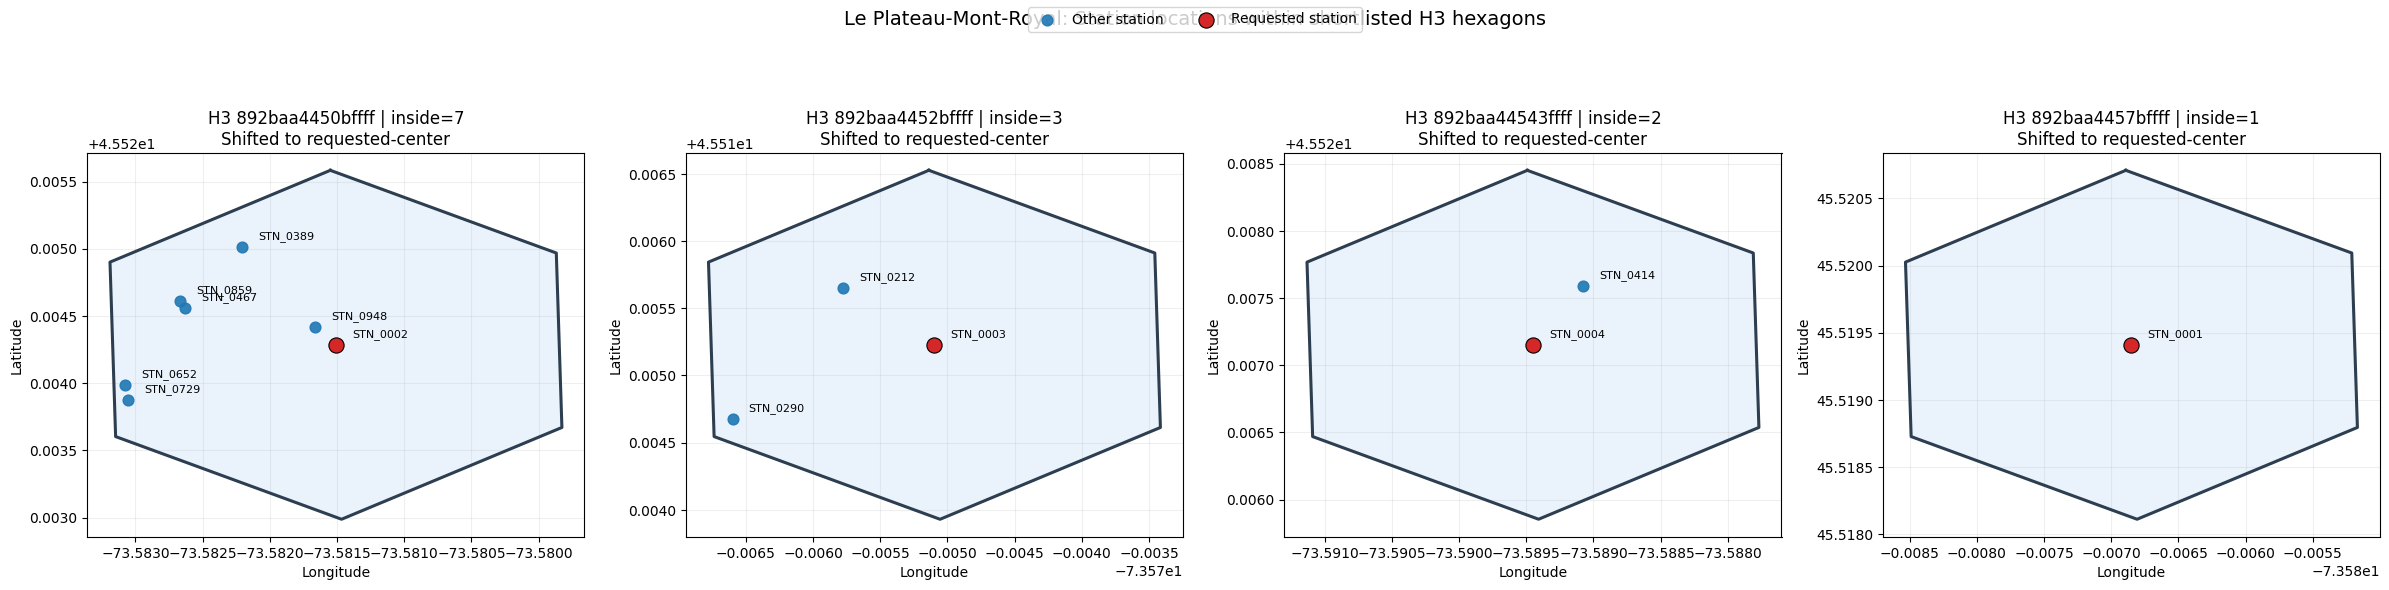

Saved shifted hex membership rows: 13


,displayed_h3_cell,station_count
0,892baa4450bffff,7
1,892baa4452bffff,3
2,892baa44543ffff,2
3,892baa4457bffff,1


In [40]:
# Task 5: Visualize station locations inside each shortlisted H3 hexagon
if "focus_df" not in globals() or "target_h3_cells" not in globals():
    raise ValueError("Run Task 3 first to create focus_df and target_h3_cells.")

if "h3_pyspark" not in globals():
    import h3_pyspark

from matplotlib.path import Path as MplPath

# Support both h3 v3 and v4 APIs through h3_pyspark handle.
if not hasattr(h3_pyspark.h3, "geo_to_h3") and hasattr(h3_pyspark.h3, "latlng_to_cell"):
    h3_pyspark.h3.geo_to_h3 = h3_pyspark.h3.latlng_to_cell

# If True, shift each displayed hexagon so its centroid is anchored to requested station(s).
# Note: this keeps hex size/orientation but no longer represents the exact fixed H3 grid location.
CENTER_HEX_ON_REQUESTED_STATION = True
CENTER_METHOD = "mean_requested"  # options: mean_requested, first_requested
HEX_SIZE_SCALE = 0.7  # <1 shrinks hexagon, >1 expands it
if HEX_SIZE_SCALE <= 0:
    raise ValueError("HEX_SIZE_SCALE must be > 0.")


def _hex_boundary_lon_lat(cell_id):
    if hasattr(h3_pyspark.h3, "h3_to_geo_boundary"):
        boundary = h3_pyspark.h3.h3_to_geo_boundary(cell_id)
    elif hasattr(h3_pyspark.h3, "cell_to_boundary"):
        boundary = h3_pyspark.h3.cell_to_boundary(cell_id)
    else:
        raise AttributeError("No supported boundary API found on h3_pyspark.h3")

    lat_lon = [(float(p[0]), float(p[1])) for p in boundary]
    lon_lat = [(lon, lat) for lat, lon in lat_lon]
    if lon_lat[0] != lon_lat[-1]:
        lon_lat.append(lon_lat[0])
    return lon_lat


def _polygon_centroid_lon_lat(lon_lat_boundary):
    pts = lon_lat_boundary[:-1] if lon_lat_boundary[0] == lon_lat_boundary[-1] else lon_lat_boundary
    pts_arr = np.array(pts, dtype=float)
    return float(np.mean(pts_arr[:, 0])), float(np.mean(pts_arr[:, 1]))


# Use candidate points from the same district only (DISTRICT_NAME).
all_station_points = station_enriched_df.copy() if "station_enriched_df" in globals() else focus_df.copy()
all_station_points = all_station_points[["canonical_station_id", "latitude", "longitude"] + (["norm_names"] if "norm_names" in all_station_points.columns else [])].copy()
if "plateau_stations_df" in globals() and "canonical_station_id" in plateau_stations_df.columns:
    district_station_ids = set(plateau_stations_df["canonical_station_id"].astype(str).tolist())
    all_station_points = all_station_points[
        all_station_points["canonical_station_id"].astype(str).isin(district_station_ids)
    ].copy()

n_cells = len(target_h3_cells)
fig, axes = plt.subplots(1, n_cells, figsize=(6 * n_cells, 6))
if n_cells == 1:
    axes = [axes]

shifted_membership_records = []

for ax, cell in zip(axes, target_h3_cells):
    # Anchor decision uses originally requested stations in this H3 cell.
    anchor_points = focus_df[focus_df["h3_cell"] == cell].copy()
    requested_points = anchor_points[anchor_points["is_requested_station"]].copy()

    boundary = _hex_boundary_lon_lat(cell)

    shifted_hex = False
    if CENTER_HEX_ON_REQUESTED_STATION and not requested_points.empty:
        if CENTER_METHOD == "first_requested":
            anchor_lon = float(requested_points.iloc[0]["longitude"] )
            anchor_lat = float(requested_points.iloc[0]["latitude"] )
        else:
            anchor_lon = float(requested_points["longitude"].mean())
            anchor_lat = float(requested_points["latitude"].mean())

        hex_center_lon, hex_center_lat = _polygon_centroid_lon_lat(boundary)
        dlon = anchor_lon - hex_center_lon
        dlat = anchor_lat - hex_center_lat
        boundary = [(lon + dlon, lat + dlat) for lon, lat in boundary]
        shifted_hex = True

    # Resize displayed hex around its centroid; affects both plot and inside-station membership.
    if HEX_SIZE_SCALE != 1.0:
        scale_center_lon, scale_center_lat = _polygon_centroid_lon_lat(boundary)
        boundary = [
            (
                scale_center_lon + (lon - scale_center_lon) * HEX_SIZE_SCALE,
                scale_center_lat + (lat - scale_center_lat) * HEX_SIZE_SCALE,
            )
            for lon, lat in boundary
        ]

    # Recompute stations that are inside the displayed (possibly shifted) hexagon.
    polygon_vertices = np.array(boundary[:-1], dtype=float)
    polygon_path = MplPath(polygon_vertices)
    candidate_xy = all_station_points[["longitude", "latitude"]].to_numpy(dtype=float)
    inside_mask = polygon_path.contains_points(candidate_xy)
    cell_points = all_station_points.loc[inside_mask].copy()

    # Mark requested stations using sanitized IDs from Task 3.
    selected_ids = set(selected_station_ids) if "selected_station_ids" in globals() else set()
    cell_points["is_requested_station"] = cell_points["canonical_station_id"].isin(selected_ids)

    # Persist panel-specific station membership for downstream analyses (e.g., monthly traffic).
    for r in cell_points.itertuples(index=False):
        shifted_membership_records.append(
            {
                "displayed_h3_cell": cell,
                "canonical_station_id": r.canonical_station_id,
                "is_requested_station": bool(r.is_requested_station),
                "latitude": float(r.latitude),
                "longitude": float(r.longitude),
            }
        )

    bx = [p[0] for p in boundary]
    by = [p[1] for p in boundary]

    # Hexagon boundary and fill
    ax.fill(bx, by, color="#DCEBFA", alpha=0.6, zorder=1)
    ax.plot(bx, by, color="#2C3E50", linewidth=2.2, zorder=2)

    # Station points (recomputed from moved hexagon).
    requested_mask = cell_points["is_requested_station"]
    ax.scatter(
        cell_points.loc[~requested_mask, "longitude"],
        cell_points.loc[~requested_mask, "latitude"],
        s=60,
        color="#1f77b4",
        alpha=0.9,
        label="Other station",
        zorder=3,
    )
    ax.scatter(
        cell_points.loc[requested_mask, "longitude"],
        cell_points.loc[requested_mask, "latitude"],
        s=120,
        color="#d62728",
        edgecolor="black",
        linewidth=0.8,
        label="Requested station",
        zorder=4,
    )

    # Label all points with station id.
    for r in cell_points.itertuples(index=False):
        ax.text(
            r.longitude + 0.00012,
            r.latitude + 0.00006,
            r.canonical_station_id,
            fontsize=8,
            zorder=5,
        )

    title_suffix = "\nShifted to requested-center" if shifted_hex else "\nNative H3 boundary"
    ax.set_title(f"H3 {cell} | inside={len(cell_points)}{title_suffix}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2)
    ax.set_aspect("equal", adjustable="box")

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

fig.suptitle(
    f"{DISTRICT_NAME}: Station locations within shortlisted H3 hexagons",
    fontsize=14,
    y=1.03,
)
plt.tight_layout()
plt.show()

shifted_hex_membership_df = pd.DataFrame(shifted_membership_records).drop_duplicates(
    subset=["displayed_h3_cell", "canonical_station_id"]
)

print("Saved shifted hex membership rows:", len(shifted_hex_membership_df))
display(
    shifted_hex_membership_df.groupby("displayed_h3_cell", as_index=False)["canonical_station_id"]
    .nunique()
    .rename(columns={"canonical_station_id": "station_count"})
    .sort_values("displayed_h3_cell")
)

,displayed_h3_cell,canonical_station_id,total_traffic
0,892baa4450bffff,STN_0002,555441
1,892baa4450bffff,STN_0389,72499
2,892baa4450bffff,STN_0467,60034
3,892baa4450bffff,STN_0652,37043
4,892baa4450bffff,STN_0729,30299
5,892baa4450bffff,STN_0859,19891
6,892baa4450bffff,STN_0948,13507
7,892baa4452bffff,STN_0003,433419
8,892baa4452bffff,STN_0212,111030
9,892baa4452bffff,STN_0290,92855


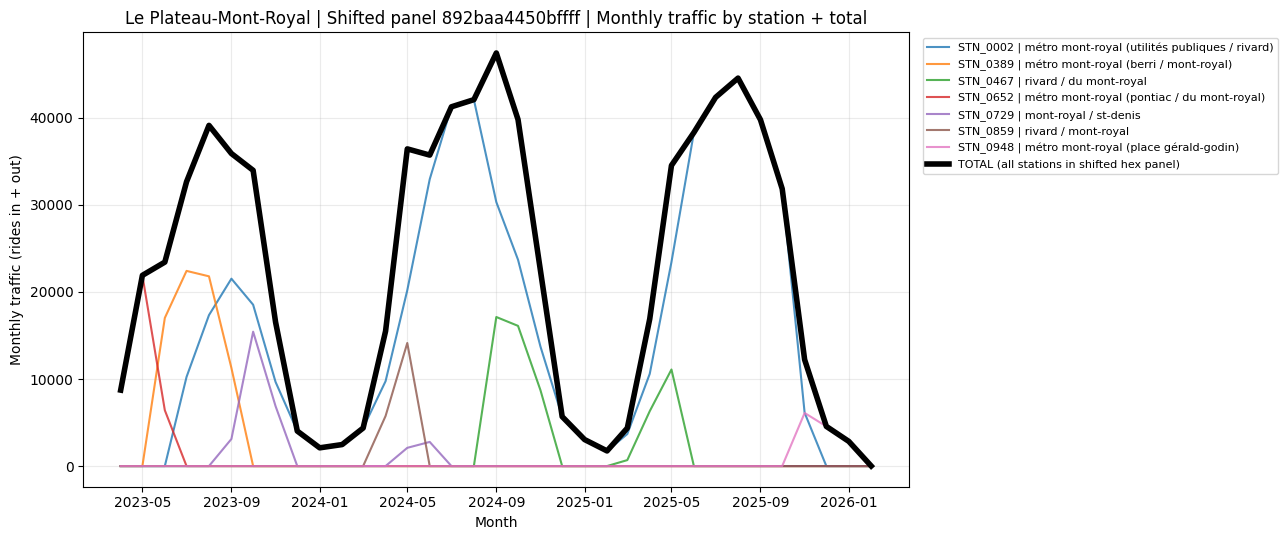

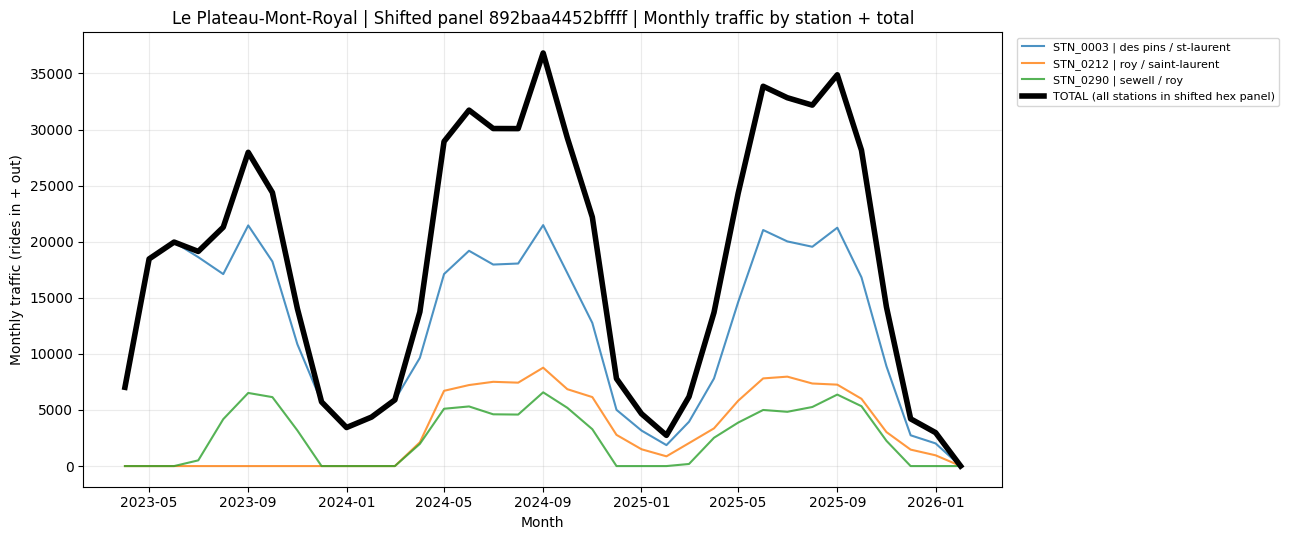

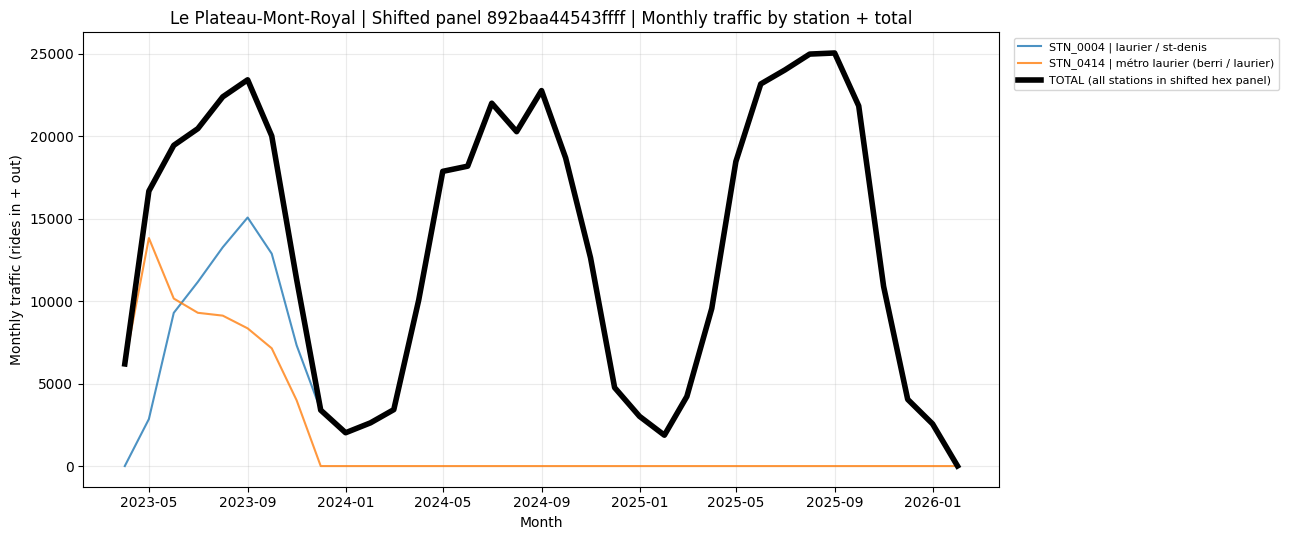

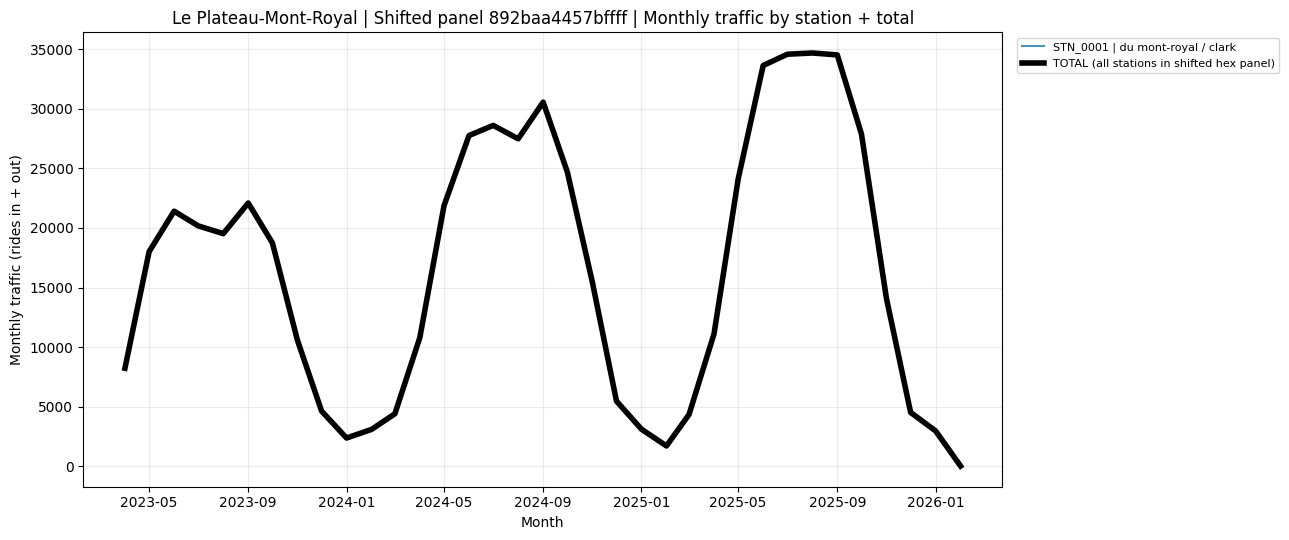

In [42]:
# Task 6: Monthly traffic using stations recomputed from Task 5 shifted hexagons
if "shifted_hex_membership_df" not in globals() or shifted_hex_membership_df.empty:
    raise ValueError("Run Task 5 first to create shifted_hex_membership_df.")

station_lookup_shifted_df = shifted_hex_membership_df[["displayed_h3_cell", "canonical_station_id"]].drop_duplicates().copy()

if "station_enriched_df" in globals() and "norm_names" in station_enriched_df.columns:
    name_map_df = station_enriched_df[["canonical_station_id", "norm_names"]].drop_duplicates(subset=["canonical_station_id"]).copy()
    name_map_df["primary_norm_name"] = name_map_df["norm_names"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "unknown"
    )
else:
    name_map_df = pd.DataFrame(
        {
            "canonical_station_id": station_lookup_shifted_df["canonical_station_id"].unique(),
            "primary_norm_name": "unknown",
        }
    )

station_lookup_shifted_df = station_lookup_shifted_df.merge(
    name_map_df[["canonical_station_id", "primary_norm_name"]],
    on="canonical_station_id",
    how="left",
)
station_lookup_shifted_df["station_label"] = station_lookup_shifted_df.apply(
    lambda r: f"{r['canonical_station_id']} | {r['primary_norm_name']}", axis=1
)

con.register(
    "station_lookup_shifted_df",
    station_lookup_shifted_df[["displayed_h3_cell", "canonical_station_id", "station_label"]],
)

monthly_shifted_sql = f"""
WITH station_flow AS (
    SELECT
        DATE_TRUNC('month', start_time_ms) AS month_ts,
        s.displayed_h3_cell,
        r.start_canonical_station_id AS canonical_station_id,
        COUNT(*)::BIGINT AS trip_count
    FROM read_parquet('{RIDES_GLOB}') r
    INNER JOIN station_lookup_shifted_df s
        ON r.start_canonical_station_id = s.canonical_station_id
    WHERE start_time_ms IS NOT NULL
    GROUP BY 1, 2, 3

    UNION ALL

    SELECT
        DATE_TRUNC('month', end_time_ms) AS month_ts,
        s.displayed_h3_cell,
        r.end_canonical_station_id AS canonical_station_id,
        COUNT(*)::BIGINT AS trip_count
    FROM read_parquet('{RIDES_GLOB}') r
    INNER JOIN station_lookup_shifted_df s
        ON r.end_canonical_station_id = s.canonical_station_id
    WHERE end_time_ms IS NOT NULL
    GROUP BY 1, 2, 3
),
station_monthly AS (
    SELECT
        month_ts,
        displayed_h3_cell,
        canonical_station_id,
        SUM(trip_count)::BIGINT AS total_traffic
    FROM station_flow
    GROUP BY 1, 2, 3
)
SELECT
    m.month_ts,
    m.displayed_h3_cell,
    s.canonical_station_id,
    s.station_label,
    m.total_traffic
FROM station_monthly m
INNER JOIN station_lookup_shifted_df s
    ON m.displayed_h3_cell = s.displayed_h3_cell
   AND m.canonical_station_id = s.canonical_station_id
ORDER BY m.displayed_h3_cell, m.month_ts, s.canonical_station_id
"""

monthly_shifted_df = con.execute(monthly_shifted_sql).df()
if monthly_shifted_df.empty:
    raise ValueError("No monthly traffic records found for Task 5 shifted-hex memberships.")

monthly_shifted_df["month_ts"] = pd.to_datetime(monthly_shifted_df["month_ts"])

shifted_summary_df = (
    monthly_shifted_df.groupby(["displayed_h3_cell", "canonical_station_id"], as_index=False)["total_traffic"]
    .sum()
    .sort_values(["displayed_h3_cell", "total_traffic"], ascending=[True, False])
)
display(shifted_summary_df)

for cell in sorted(monthly_shifted_df["displayed_h3_cell"].unique().tolist()):
    cell_df = monthly_shifted_df[monthly_shifted_df["displayed_h3_cell"] == cell].copy()
    if cell_df.empty:
        continue

    pivot_df = (
        cell_df.pivot_table(
            index="month_ts",
            columns="station_label",
            values="total_traffic",
            aggfunc="sum",
            fill_value=0,
        )
        .sort_index()
    )

    total_series = pivot_df.sum(axis=1)

    fig, ax = plt.subplots(figsize=(13, 5.5))

    for station_col in pivot_df.columns:
        ax.plot(
            pivot_df.index,
            pivot_df[station_col],
            linewidth=1.5,
            alpha=0.8,
            label=station_col,
        )

    ax.plot(
        total_series.index,
        total_series.values,
        linewidth=4,
        color="black",
        label="TOTAL (all stations in shifted hex panel)",
        zorder=10,
    )

    ax.set_title(f"{DISTRICT_NAME} | Shifted panel {cell} | Monthly traffic by station + total")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly traffic (rides in + out)")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.show()